# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset yang digunakan dalam proyek ini adalah Titanic - Machine Learning from Disaster yang diperoleh dari platform Kaggle. Dataset ini berisi informasi mengenai penumpang kapal Titanic dan digunakan untuk memprediksi apakah seorang penumpang selamat atau tidak.
   
   Dataset terdiri dari beberapa fitur seperti usia (Age), jenis kelamin (Sex), kelas tiket (Pclass), jumlah keluarga (SibSp dan Parch), serta informasi lainnya. Variabel target yang digunakan adalah Survived, dengan nilai 0 (tidak selamat) dan 1 (selamat).

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [16]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

===== HEAD =====
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   

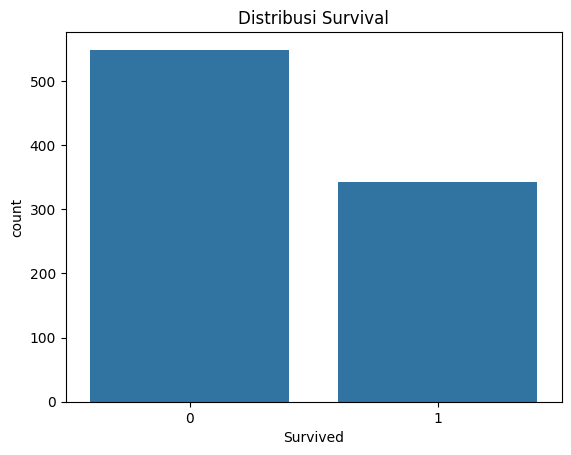

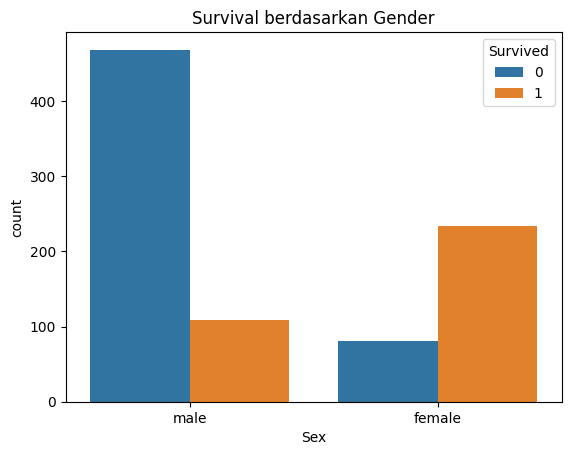

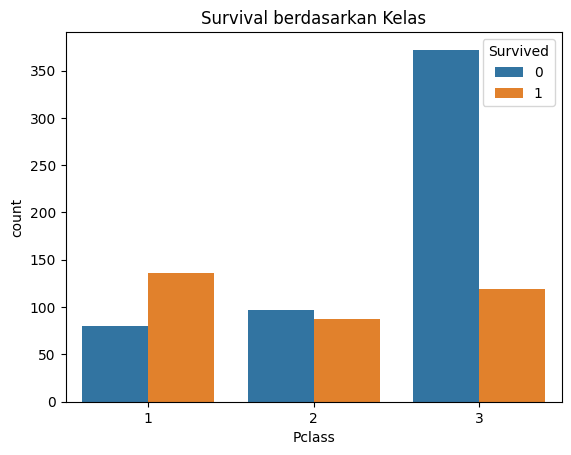

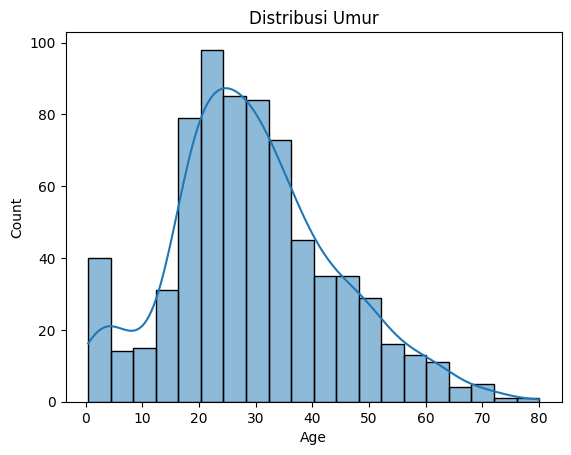

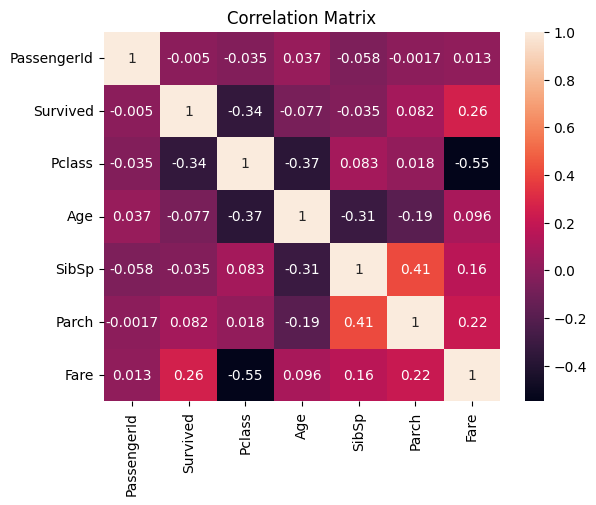

In [17]:
# =======================
# EXPLORATORY DATA ANALYSIS
# =======================

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Melihat data awal
print("===== HEAD =====")
print(train.head())

# 2. Informasi dataset
print("\n===== INFO =====")
print(train.info())

# 3. Statistik deskriptif
print("\n===== DESCRIBE =====")
print(train.describe())

# 4. Cek missing values
print("\n===== MISSING VALUES =====")
print(train.isnull().sum())

# =======================
# VISUALISASI
# =======================

# Distribusi target
plt.figure()
sns.countplot(x='Survived', data=train)
plt.title('Distribusi Survival')
plt.show()

# Gender vs Survival
plt.figure()
sns.countplot(x='Sex', hue='Survived', data=train)
plt.title('Survival berdasarkan Gender')
plt.show()

# Class vs Survival
plt.figure()
sns.countplot(x='Pclass', hue='Survived', data=train)
plt.title('Survival berdasarkan Kelas')
plt.show()

# Distribusi Age
plt.figure()
sns.histplot(train['Age'].dropna(), kde=True)
plt.title('Distribusi Umur')
plt.show()

# Korelasi
plt.figure()
sns.heatmap(train.corr(numeric_only=True), annot=True)
plt.title('Correlation Matrix')
plt.show()

### Insight EDA

1. Sebagian besar penumpang tidak selamat.
2. Perempuan memiliki peluang selamat lebih tinggi dibanding laki-laki.
3. Penumpang kelas 1 lebih banyak yang selamat dibanding kelas 3.
4. Terdapat missing values pada kolom Age, Cabin, dan Embarked.
5. Distribusi umur didominasi usia dewasa.

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [18]:
# =======================
# DATA PREPROCESSING
# =======================

df = train.copy()

# =======================
# 1. Missing Values
# =======================
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin
df = df.drop(columns=['Cabin'])

# =======================
# 2. Drop Kolom Tidak Penting
# =======================
df = df.drop(columns=['PassengerId', 'Name', 'Ticket'])

# =======================
# 3. Encoding
# =======================
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# =======================
# 4. Feature Engineering
# =======================
df['FamilySize'] = df['SibSp'] + df['Parch']

# =======================
# 5. Final Check
# =======================
print(df.head())
print("\nShape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S  \
0         0       3    0  22.0      1      0   7.2500       False        True   
1         1       1    1  38.0      1      0  71.2833       False       False   
2         1       3    1  26.0      0      0   7.9250       False        True   
3         1       1    1  35.0      1      0  53.1000       False        True   
4         0       3    0  35.0      0      0   8.0500       False        True   

   FamilySize  
0           1  
1           1  
2           0  
3           1  
4           0  

Shape: (891, 10)

Missing values:
 Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
FamilySize    0
dtype: int64


### Insight Preprocessing

1. Missing values pada kolom Age diisi menggunakan median.
2. Missing values pada Embarked diisi menggunakan modus.
3. Kolom Cabin dihapus karena terlalu banyak nilai kosong.
4. Kolom yang tidak relevan seperti PassengerId, Name, dan Ticket dihapus.
5. Variabel kategorikal diubah menjadi numerik menggunakan encoding.
6. Dibuat fitur baru yaitu FamilySize untuk meningkatkan informasi.